# ml in our life 
# fruad detection stock price house price recommdation system biliology adn diagnosal the sickness nowadays llms and nlp models 

# in general we have 3 main model of ml supervise earning and unsupervise ;earning and deep learning  in supervise we have the data nd the answer of them form the past and we need to based on our data put some alghorthim to predict the futire pof our targetrs supervise alghorthim will be : linear regression logisitic regression svm desicsion treee random forest easmblers ( xgboost , atboost,lighgboost ,  kNN , )


 # in unsupervise learning we have the assosation clustering and reduction dimention  


 # also multy classes and clasees : ts when we have data that some of our future have not just one class but msny class we see and in normal classes it basically means that we have for each data it sepecefic classes  

In [612]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sys 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder , PolynomialFeatures
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score , mean_squared_error , mean_absolute_error

In [613]:
jsonfile= pd.read_json("../datasets/train.json")
jsonfile.to_clipboard

<bound method NDFrame.to_clipboard of         bathrooms  bedrooms                       building_id  \
4             1.0         1  8579a0b0d54db803821a35a4a615e97a   
6             1.0         2  b8e75fc949a6cd8225b455648a951712   
9             1.0         2  cd759a988b8f23924b5a2058d5ab2b49   
10            1.5         3  53a5b119ba8f7b61d4e010512e0dfc85   
15            1.0         0  bfb9405149bfff42a92980b594c28234   
...           ...       ...                               ...   
124000        1.0         3  92bbbf38baadfde0576fc496bd41749c   
124002        1.0         2  5565db9b7cba3603834c4aa6f2950960   
124004        1.0         1  67997a128056ee1ed7d046bbb856e3c7   
124008        1.0         2  3c0574a740154806c18bdf1fddd3d966   
124009        1.0         3  d89f514c3ed0abaae52cba7017ac0701   

                    created  \
4       2016-06-16 05:55:27   
6       2016-06-01 05:44:33   
9       2016-06-14 15:19:59   
10      2016-06-24 07:54:24   
15      2016-06-28 03:50:2

In [614]:
f"this is the shape of our data {jsonfile.shape}"
jsonfile.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

In [615]:
jsonfile.dtypes
jsonfilenumber = jsonfile.select_dtypes(include=[np.number])
jsonfilenumber.dtypes


bathrooms     float64
bedrooms        int64
latitude      float64
listing_id      int64
longitude     float64
price           int64
dtype: object

In [616]:
print(jsonfilenumber.corr())
power2 = jsonfilenumber[:][::]**2

power2.describe()


            bathrooms  bedrooms  latitude  listing_id  longitude     price
bathrooms    1.000000  0.533446 -0.009657    0.000776   0.010393  0.069661
bedrooms     0.533446  1.000000 -0.004745    0.011968   0.006892  0.051788
latitude    -0.009657 -0.004745  1.000000    0.001712  -0.966807 -0.000707
listing_id   0.000776  0.011968  0.001712    1.000000  -0.000907  0.008090
longitude    0.010393  0.006892 -0.966807   -0.000907   1.000000 -0.000087
price        0.069661  0.051788 -0.000707    0.008090  -0.000087  1.000000


,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.000000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.720797,3.619894,1660.281194,4.935329e+13,5470.835307,5.016069e+08
std,1.961205,4.301636,26.397593,1.778057e+12,95.930773,9.123496e+10
min,0.000000,0.000000,0.000000,4.640276e+13,0.000000,1.849000e+03
25%,1.000000,1.000000,1658.794421,4.782950e+13,5469.312443,6.250000e+06
50%,1.000000,1.000000,1660.709203,4.929543e+13,5472.729688,9.922500e+06
75%,1.000000,4.000000,1662.543540,5.081884e+13,5474.771669,1.681000e+07
max,100.000000,64.000000,2014.528572,6.012117e+13,13988.029441,2.016010e+13


In [617]:
jsonfile.columns
target = jsonfile['price']
futures = jsonfile[['bathrooms', 'bedrooms','interest_level']]
dataa = jsonfile[['bathrooms', 'bedrooms','interest_level','price']]
dataa

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


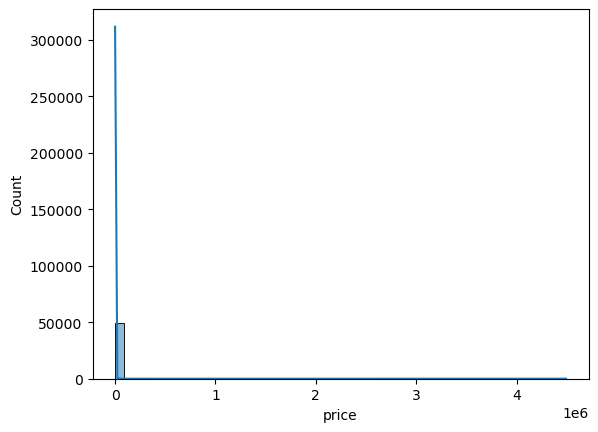

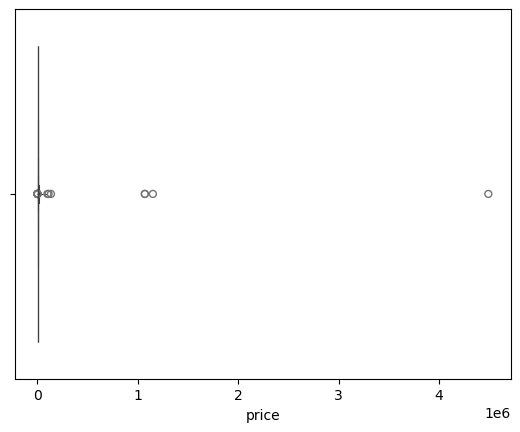

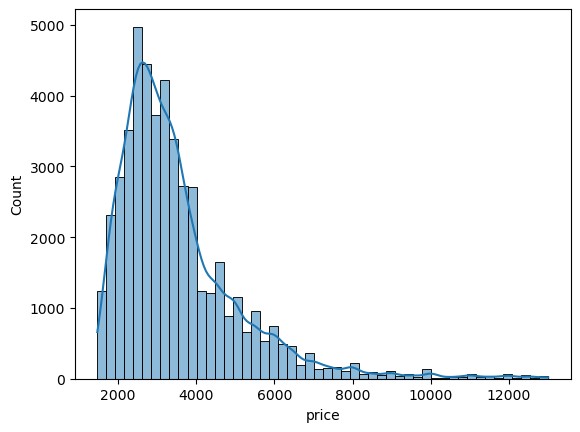

In [618]:
sns.histplot(dataa['price'],bins=50,kde=True)
plt.show()


sns.boxenplot(x=dataa['price'])
plt.show()

lower_bound =dataa['price'].quantile(0.01)
upper_bound = dataa['price'].quantile(0.99)
dataaclean = dataa[(dataa['price'] >= lower_bound) & (dataa['price'] <= upper_bound)].copy()

sns.histplot(dataaclean['price'],bins=50,kde=True)
plt.show()

In [619]:
dataa.interest_level

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 49352, dtype: object

In [620]:
label = LabelEncoder()
dataa['interest_level'] = label.fit_transform(dataa['interest_level'])
y = dataa['price']
x = dataa[['bathrooms','bedrooms','interest_level']]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
poly = PolynomialFeatures(degree=10)
linear = LinearRegression()
tree = DecisionTreeRegressor(max_depth=5, random_state=21)
polyx= poly.fit_transform(x_train)
xpolytest = poly.transform(x_test)
linear.fit(polyx,y_train)
y_predict = linear.predict(polyx)
y_predict_test = linear.predict(xpolytest)
accuracy = mean_absolute_error(y_predict,y_train)
accuracy2 = mean_absolute_error(y_predict_test,y_test)
tree.fit(polyx,y_train)
y_predict = tree.predict(polyx)
y_predict_test = tree.predict(xpolytest)
accuracy3 = mean_absolute_error(y_predict,y_train)
accuracy4 = mean_absolute_error(y_predict_test,y_test)
print(accuracy)
print(accuracy2)
print(accuracy3)
print(accuracy4)


C:\Users\hosse\AppData\Local\Temp\ipykernel_888\2332885756.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataa['interest_level'] = label.fit_transform(dataa['interest_level'])


913.8416541473754
1298.121878700214
927.9108476009765
1309.311246740586


Text(0.5, 1.0, 'Гистограмма: Bedrooms')

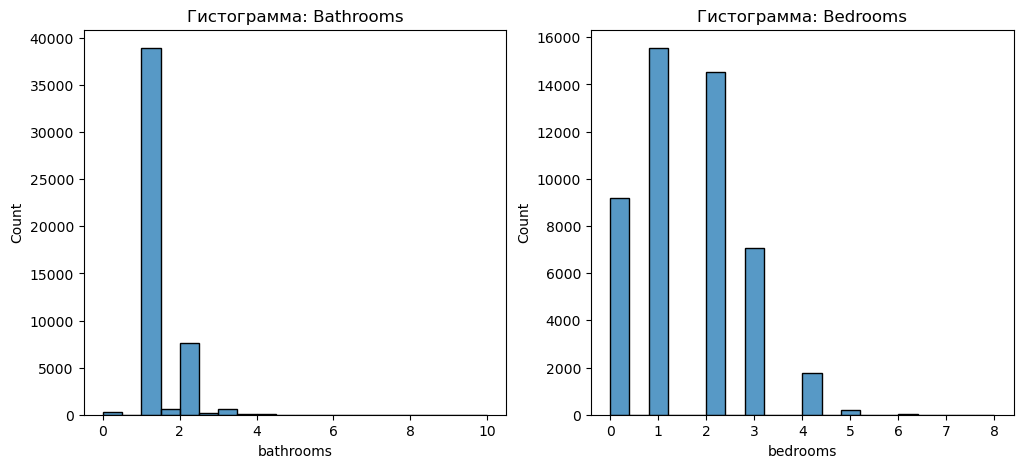

In [621]:
from sklearn.preprocessing import OrdinalEncoder

dataaclean['interest_level']
label = LabelEncoder()
dataaclean['interest_label'] = label.fit_transform(dataaclean['interest_level'])
dataaclean = dataaclean[['bathrooms'	,'bedrooms' ,'interest_label' , 'price']]

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(dataaclean['bathrooms'], bins=20, kde=False)
plt.title('Гистограмма: Bathrooms')

plt.subplot(1, 2, 2)
sns.histplot(dataaclean['bedrooms'], bins=20, kde=False)
plt.title('Гистограмма: Bedrooms')


In [622]:
dataaclean

,bathrooms,bedrooms,interest_label,price
4,1.0,1,2,2400
6,1.0,2,1,3800
9,1.0,2,2,3495
10,1.5,3,2,3000
15,1.0,0,1,2795
...,...,...,...,...
124000,1.0,3,1,2800
124002,1.0,2,2,2395
124004,1.0,1,2,1850
124008,1.0,2,2,4195


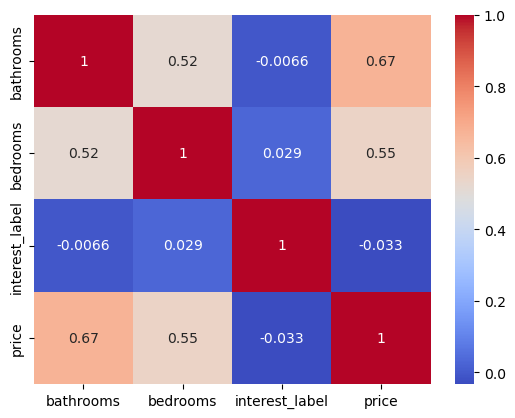

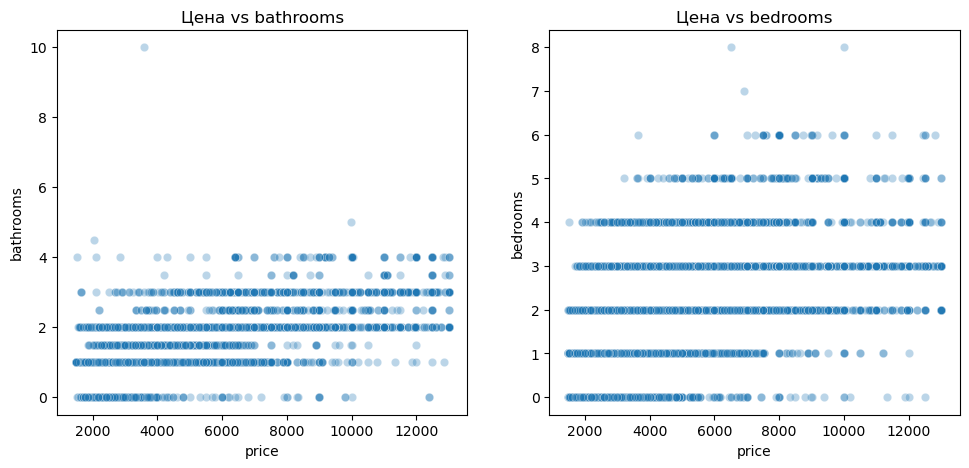

In [623]:
dfanalyst =dataaclean
heat = dfanalyst.corr()
sns.heatmap(data=heat, annot=True,cmap='coolwarm')
plt.show()
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.scatterplot(x='price', y='bathrooms', data=dfanalyst, alpha=0.3)
plt.title('Цена vs bathrooms')

plt.subplot(1,3,2)
sns.scatterplot(x='price', y='bedrooms', data=dfanalyst, alpha=0.3)
plt.title('Цена vs bedrooms')


plt.show()


In [624]:
from sklearn.metrics import r2_score
y = dataaclean['price']
x = dataaclean[['bathrooms', 'bedrooms']]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size= 0.2 , random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

poly = PolynomialFeatures(degree=5)
xtrainpoly = poly.fit_transform(x_train)
xtestpoly = poly.transform(x_test)

lin  = LinearRegression()
lin.fit(xtrainpoly,y_train)

tree = DecisionTreeRegressor(random_state=21)
tree.fit(xtrainpoly,y_train)
ydectrain =tree.predict(xtrainpoly)
ydectest =tree.predict(xtestpoly)

ytrainpr= lin.predict(xtrainpoly)
ytestpr = lin.predict(xtestpoly)
r2_score(ytrainpr,y_train)
r2_score(ytestpr,y_test)
w1=mean_absolute_error(ytrainpr,y_train)
w2=mean_absolute_error(ytestpr,y_test)
w1=mean_absolute_error(ytrainpr,y_train)
w2=mean_absolute_error(ydectrain,y_train)
w3=mean_absolute_error(ytrainpr,y_train)
w4=mean_absolute_error(ydectest,y_test)
w5 = np.mean(np.abs((y_train - ytrainpr)/ y_train)) * 100
w6  = np.mean(np.abs((y_test - ytestpr) / y_test)) * 100

yy = y_train.mean()
yyy = y_test.mean()
yyyy = y_train.median()
yyyyy = y_test.median()

train_pred_mean = np.full_like(y_train, yy)
test_pred_mean = np.full_like(y_test, yyy)
train_pred_median = np.full_like(y_train, yyyy)
test_pred_median = np.full_like(y_test, yyyyy)

mae_train_median = mean_absolute_error(y_train, train_pred_median)
mae_test_median = mean_absolute_error(y_test, test_pred_median)
rmse_train_median = np.sqrt(mean_squared_error(y_train, train_pred_median))
rmse_test_median = np.sqrt(mean_squared_error(y_test, test_pred_median))

mae_train_mean = mean_absolute_error(y_train, train_pred_mean)
mae_test_mean = mean_absolute_error(y_test, test_pred_mean)
rmse_train_mean = np.sqrt(mean_squared_error(y_train, train_pred_mean))
rmse_test_mean = np.sqrt(mean_squared_error(y_test, test_pred_mean))


new_row_mae_mean = pd.DataFrame({'model': ['naive_mean'], 'train': [mae_train_mean], 'test': [mae_test_mean]})
new_row_mae_median = pd.DataFrame({'model': ['naive_median'], 'train': [mae_train_median], 'test': [mae_test_median]})
new_row_rmse_mean = pd.DataFrame({'model': ['naive_mean'], 'train': [rmse_train_mean], 'test': [rmse_test_mean]})
new_row_rmse_median = pd.DataFrame({'model': ['naive_median'], 'train': [rmse_train_median], 'test': [rmse_test_median]})

result_MAE = pd.concat([new_row_mae_mean, new_row_mae_median], ignore_index=True)
result_RMSE = pd.concat([new_row_rmse_mean, new_row_rmse_median], ignore_index=True)
result_MAE
result_RMSE



,model,train,test
0,naive_mean,1599.229473,1591.287964
1,naive_median,1645.449541,1635.833581


In [625]:
q1 = dataa['bedrooms'].quantile(0.01)
q2 = dataa['bedrooms'].quantile(0.99)
iqr = q2 - q1
dataaclean = dataa[(dataa['bedrooms'] > q1) & (dataa['bedrooms']< q2)]
q1 = dataa['bathrooms'].quantile(0.01)
q2 = dataa['bathrooms'].quantile(0.99)
iqr = q2 - q1
dataaclean = dataa[(dataa['bathrooms'] >(q1)) & (dataa['bathrooms']< (q2))]

dataaclean.corr()

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.126293,0.014908,0.289426
bedrooms,0.126293,1.000000,0.084749,0.093841
interest_level,0.014908,0.084749,1.000000,-0.076068
price,0.289426,0.093841,-0.076068,1.000000


In [626]:
polyy = PolynomialFeatures(degree=2,include_bias=False)
xs = polyy.fit_transform(x_train)
dataaclean['all'] = dataaclean['bathrooms'] * dataaclean['bedrooms']
x = dataaclean[['bathrooms','bedrooms','all']]
polyy = PolynomialFeatures(degree=2,include_bias=False)
xs = polyy.fit_transform(x_train)
dataaclean['all'] = dataaclean['bathrooms'] * dataaclean['bedrooms']
x = dataaclean[['bathrooms','bedrooms','all']]


x_train , x_test , y_train , y_test = train_test_split(x,y,test_size= 0.2 , random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

poly = PolynomialFeatures(degree=5)
xtrainpoly = poly.fit_transform(x_train)
xtestpoly = poly.transform(x_test)

lin  = LinearRegression()
lin.fit(xtrainpoly,y_train)

tree = DecisionTreeRegressor(random_state=21)
tree.fit(xtrainpoly,y_train)
ydectrain =tree.predict(xtrainpoly)
ydectest =tree.predict(xtestpoly)

ytrainpr= lin.predict(xtrainpoly)
ytestpr = lin.predict(xtestpoly)
r2_score(ytrainpr,y_train)
r2_score(ytestpr,y_test)
w1=mean_absolute_error(ytrainpr,y_train)
w2=mean_absolute_error(ytestpr,y_test)
w1=mean_absolute_error(ytrainpr,y_train)
w2=mean_absolute_error(ydectrain,y_train)
w3=mean_absolute_error(ytrainpr,y_train)
w4=mean_absolute_error(ydectest,y_test)
w5 = np.mean(np.abs((y_train - ytrainpr)/ y_train)) * 100
w6  = np.mean(np.abs((y_test - ytestpr) / y_test)) * 100
w1,w2,w3,w4,w5,w6

C:\Users\hosse\AppData\Local\Temp\ipykernel_888\3221962846.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataaclean['all'] = dataaclean['bathrooms'] * dataaclean['bedrooms']
C:\Users\hosse\AppData\Local\Temp\ipykernel_888\3221962846.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataaclean['all'] = dataaclean['bathrooms'] * dataaclean['bedrooms']


ValueError: Found input variables with inconsistent numbers of samples: [8582, 48379]